# Deep Learning
MATH 70116<br>
Autumn 2026<br>
Lecturer: Tom Hadfield
# OR, AND, NAND, XOR
### approximate these functions by neural networks of various depths and sizes

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. OR

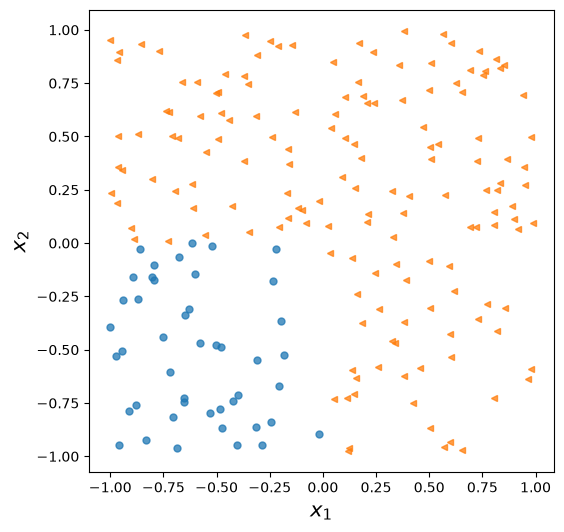

In [2]:
torch.manual_seed(1)
np.random.seed(1)
x = np.random.uniform(low=-1, high=1, size=(200,2))
y = np.ones(len(x))

# define OR:
y[(x[:,0] < 0) & (x[:,1] < 0)] = 0

n_train = 100
x_train = torch.tensor(x[:n_train,:], dtype = torch.float32)
y_train = torch.tensor(y[:n_train], dtype = torch.float32)
x_valid = torch.tensor(x[n_train:,:], dtype = torch.float32)
y_valid = torch.tensor(y[n_train:], dtype = torch.float32)

fig = plt.figure(figsize=(6,6))
plt.plot(x[y==0,0],x[y==0,1],'o',alpha=0.75, markersize=5)
plt.plot(x[y==1,0],x[y==1,1],'<',alpha=0.75, markersize=5)
plt.xlabel(r'$x_1$', size=15)
plt.ylabel(r'$x_2$', size=15)
plt.show()

## 1.1. Simple benchmark : Single Layer Logistic Regression

In [3]:
sllr = nn.Sequential(
	nn.Linear(2,1),
	nn.Sigmoid()
	)

In [4]:
print(sllr)

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
  (1): Sigmoid()
)


In [5]:
eta = 0.01
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(sllr.parameters(), lr = eta)

In [7]:
num_epochs = 2000

train = train_model(sllr,
    x_train,
    y_train,
    loss_fn,
    optimizer,
    epochs = num_epochs,
    batch_size=32,
    metrics=None,
    X_val=x_valid,
    y_val=y_valid,
    validation_split=0.0,
    verbose_every=1,
    device=None,)

Epoch 1/2000, loss: 0.7450, val_loss: 0.7457
Epoch 2/2000, loss: 0.7399, val_loss: 0.7406
Epoch 3/2000, loss: 0.7352, val_loss: 0.7352
Epoch 4/2000, loss: 0.7303, val_loss: 0.7310
Epoch 5/2000, loss: 0.7262, val_loss: 0.7258
Epoch 6/2000, loss: 0.7215, val_loss: 0.7210
Epoch 7/2000, loss: 0.7171, val_loss: 0.7156
Epoch 8/2000, loss: 0.7121, val_loss: 0.7104
Epoch 9/2000, loss: 0.7074, val_loss: 0.7051
Epoch 10/2000, loss: 0.7025, val_loss: 0.7001
Epoch 11/2000, loss: 0.6980, val_loss: 0.6954
Epoch 12/2000, loss: 0.6937, val_loss: 0.6915
Epoch 13/2000, loss: 0.6900, val_loss: 0.6871
Epoch 14/2000, loss: 0.6860, val_loss: 0.6826
Epoch 15/2000, loss: 0.6819, val_loss: 0.6779
Epoch 16/2000, loss: 0.6775, val_loss: 0.6729
Epoch 17/2000, loss: 0.6730, val_loss: 0.6687
Epoch 18/2000, loss: 0.6692, val_loss: 0.6653
Epoch 19/2000, loss: 0.6661, val_loss: 0.6614
Epoch 20/2000, loss: 0.6625, val_loss: 0.6574
Epoch 21/2000, loss: 0.6587, val_loss: 0.6537
Epoch 22/2000, loss: 0.6552, val_loss: 0.64

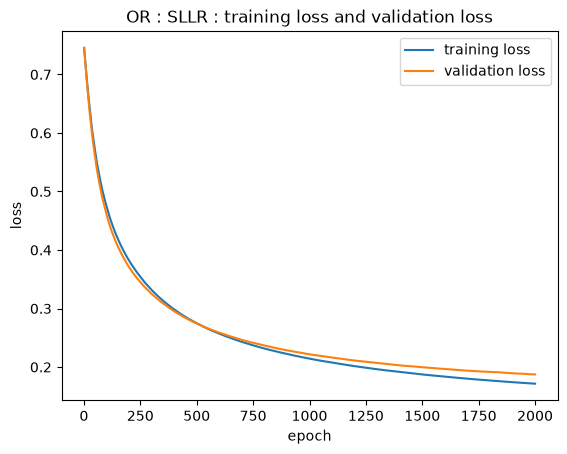

In [8]:
train_loss_vals = train['loss']
validation_loss_vals = train['val_loss']
epoch_vals = np.arange(1, len(train_loss_vals) + 1)

this_title = "OR : SLLR : training loss and validation loss"
plt.plot(epoch_vals, train_loss_vals, label = "training loss")
plt.plot(epoch_vals, validation_loss_vals, label = "validation loss")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(this_title)
plt.show()


# evaluate on some new data

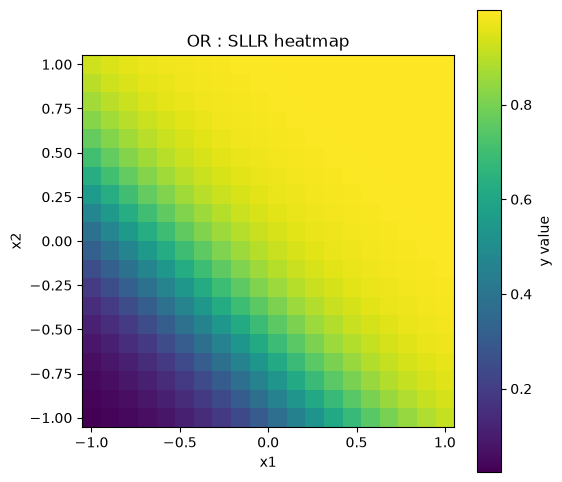

In [9]:
N = 20  # number of points along each axis

x1 = np.linspace(-1, 1, N)
x2 = np.linspace(-1, 1, N)
xx1, xx2 = np.meshgrid(x1, x2)

x_new = np.stack([xx1.ravel(), xx2.ravel()], axis=1)

y_new = model_predict(sllr, x_new)

y_grid_2d = y_new.reshape(N, N)

plt.figure(figsize=(6, 6))
plt.pcolormesh(xx1, xx2, y_grid_2d, cmap="viridis", shading="auto")
plt.colorbar(label="y value")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("OR : SLLR heatmap")
plt.gca().set_aspect("equal")
plt.show()

# 1.2. Now use a model with more layers

In [10]:
n = 200

model = nn.Sequential(
	nn.Linear(2,n),
	nn.ReLU(),
	nn.Linear(n,n),
	nn.ReLU(),
    nn.Linear(n,n),
	nn.ReLU(),
	nn.Linear(n,1),
	nn.Sigmoid()
	)

eta = 0.01
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = eta)
print(model)

Sequential(
  (0): Linear(in_features=2, out_features=200, bias=True)
  (1): ReLU()
  (2): Linear(in_features=200, out_features=200, bias=True)
  (3): ReLU()
  (4): Linear(in_features=200, out_features=200, bias=True)
  (5): ReLU()
  (6): Linear(in_features=200, out_features=1, bias=True)
  (7): Sigmoid()
)


In [11]:
num_epochs = 500

train = train_model(model,
    x_train,
    y_train,
    loss_fn,
    optimizer,
    epochs = num_epochs,
    batch_size=32,
    metrics=None,
    X_val=x_valid,
    y_val=y_valid,
    validation_split=0.0,
    verbose_every=1,
    device=None,)

Epoch 1/500, loss: 0.6869, val_loss: 0.6802
Epoch 2/500, loss: 0.6793, val_loss: 0.6708
Epoch 3/500, loss: 0.6714, val_loss: 0.6642
Epoch 4/500, loss: 0.6654, val_loss: 0.6562
Epoch 5/500, loss: 0.6585, val_loss: 0.6485
Epoch 6/500, loss: 0.6519, val_loss: 0.6423
Epoch 7/500, loss: 0.6462, val_loss: 0.6335
Epoch 8/500, loss: 0.6389, val_loss: 0.6250
Epoch 9/500, loss: 0.6319, val_loss: 0.6178
Epoch 10/500, loss: 0.6254, val_loss: 0.6105
Epoch 11/500, loss: 0.6191, val_loss: 0.6036
Epoch 12/500, loss: 0.6130, val_loss: 0.5963
Epoch 13/500, loss: 0.6068, val_loss: 0.5893
Epoch 14/500, loss: 0.6005, val_loss: 0.5822
Epoch 15/500, loss: 0.5941, val_loss: 0.5752
Epoch 16/500, loss: 0.5878, val_loss: 0.5669
Epoch 17/500, loss: 0.5808, val_loss: 0.5602
Epoch 18/500, loss: 0.5747, val_loss: 0.5533
Epoch 19/500, loss: 0.5685, val_loss: 0.5463
Epoch 20/500, loss: 0.5623, val_loss: 0.5385
Epoch 21/500, loss: 0.5557, val_loss: 0.5309
Epoch 22/500, loss: 0.5490, val_loss: 0.5230
Epoch 23/500, loss:

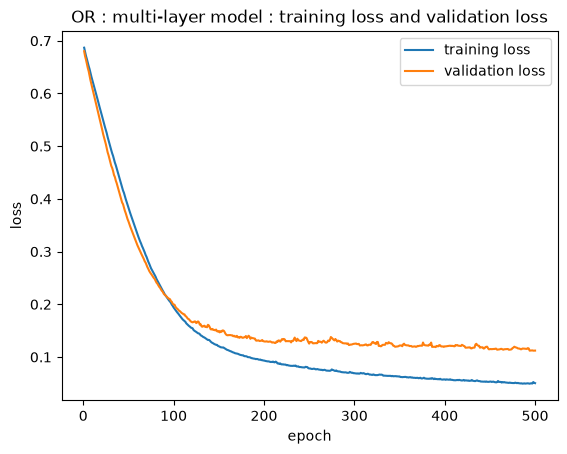

In [12]:
train_loss_vals = train['loss']
validation_loss_vals = train['val_loss']
epoch_vals = np.arange(1, len(train_loss_vals) + 1)

this_title = "OR : multi-layer model : training loss and validation loss"
plt.plot(epoch_vals, train_loss_vals, label = "training loss")
plt.plot(epoch_vals, validation_loss_vals, label = "validation loss")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(this_title)
plt.show()

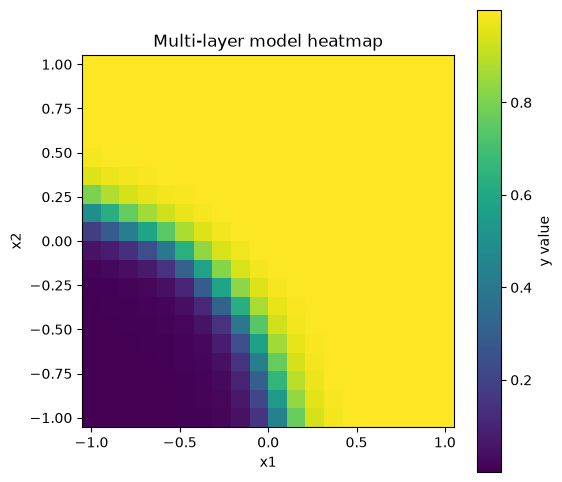

In [13]:
N = 20  # number of points along each axis

x1 = np.linspace(-1, 1, N)
x2 = np.linspace(-1, 1, N)
xx1, xx2 = np.meshgrid(x1, x2)
x_new = np.stack([xx1.ravel(), xx2.ravel()], axis=1)
y_new = model_predict(model, x_new)
y_grid_2d = y_new.reshape(N, N)

plt.figure(figsize=(6, 6))
plt.pcolormesh(xx1, xx2, y_grid_2d, cmap="viridis", shading="auto")
plt.colorbar(label="y value")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Multi-layer model heatmap")
plt.gca().set_aspect("equal")
plt.show()

# 2. Exercise : repeat the above, for AND

# 3. Exercise : repeat the above, for NAND

# 4. XOR

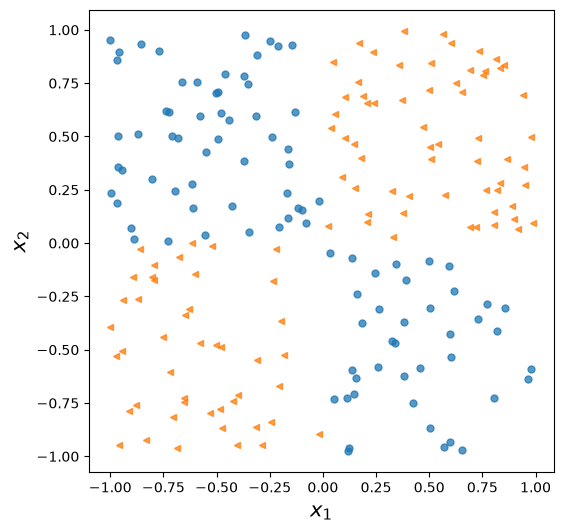

In [14]:
torch.manual_seed(1)
np.random.seed(1)
x = np.random.uniform(low=-1, high=1, size=(200,2))
y = np.ones(len(x))

# define XOR:
y[x[:,0]*x[:,1] < 0] = 0

n_train = 100
x_train = torch.tensor(x[:n_train,:], dtype = torch.float32)
y_train = torch.tensor(y[:n_train], dtype = torch.float32)
x_valid = torch.tensor(x[n_train:,:], dtype = torch.float32)
y_valid = torch.tensor(y[n_train:], dtype = torch.float32)

fig = plt.figure(figsize=(6,6))
plt.plot(x[y==0,0],x[y==0,1],'o',alpha=0.75, markersize=5)
plt.plot(x[y==1,0],x[y==1,1],'<',alpha=0.75, markersize=5)
plt.xlabel(r'$x_1$', size=15)
plt.ylabel(r'$x_2$', size=15)
plt.show()

## 4.1. Simple benchmark : Single Layer Logistic Regression

In [15]:
sllr = nn.Sequential(
	nn.Linear(2,1),
	nn.Sigmoid()
	)

In [16]:
print(sllr)

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
  (1): Sigmoid()
)


In [17]:
eta = 0.01
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(sllr.parameters(), lr = eta)

In [18]:
num_epochs = 2000

train = train_model(sllr,
    x_train,
    y_train,
    loss_fn,
    optimizer,
    epochs = num_epochs,
    batch_size=32,
    metrics=None,
    X_val=x_valid,
    y_val=y_valid,
    validation_split=0.0,
    verbose_every=1,
    device=None,)

Epoch 1/2000, loss: 0.6970, val_loss: 0.6905
Epoch 2/2000, loss: 0.6970, val_loss: 0.6903
Epoch 3/2000, loss: 0.6969, val_loss: 0.6903
Epoch 4/2000, loss: 0.6968, val_loss: 0.6899
Epoch 5/2000, loss: 0.6963, val_loss: 0.6897
Epoch 6/2000, loss: 0.6961, val_loss: 0.6897
Epoch 7/2000, loss: 0.6961, val_loss: 0.6896
Epoch 8/2000, loss: 0.6959, val_loss: 0.6894
Epoch 9/2000, loss: 0.6957, val_loss: 0.6893
Epoch 10/2000, loss: 0.6956, val_loss: 0.6893
Epoch 11/2000, loss: 0.6957, val_loss: 0.6892
Epoch 12/2000, loss: 0.6955, val_loss: 0.6892
Epoch 13/2000, loss: 0.6953, val_loss: 0.6890
Epoch 14/2000, loss: 0.6952, val_loss: 0.6891
Epoch 15/2000, loss: 0.6952, val_loss: 0.6888
Epoch 16/2000, loss: 0.6950, val_loss: 0.6888
Epoch 17/2000, loss: 0.6950, val_loss: 0.6888
Epoch 18/2000, loss: 0.6949, val_loss: 0.6887
Epoch 19/2000, loss: 0.6948, val_loss: 0.6887
Epoch 20/2000, loss: 0.6947, val_loss: 0.6886
Epoch 21/2000, loss: 0.6946, val_loss: 0.6884
Epoch 22/2000, loss: 0.6942, val_loss: 0.68

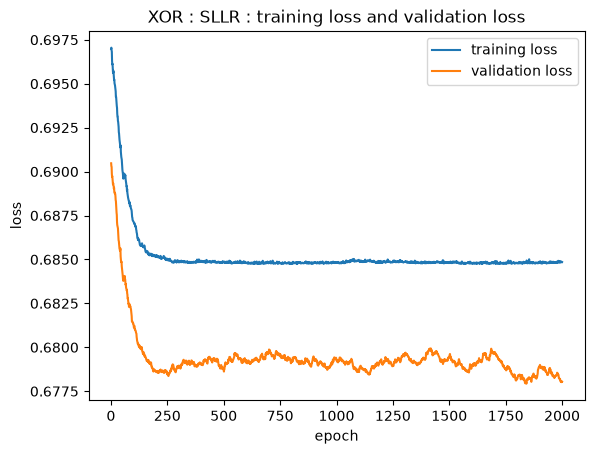

In [19]:
train_loss_vals = train['loss']
validation_loss_vals = train['val_loss']
epoch_vals = np.arange(1, len(train_loss_vals) + 1)

this_title = "XOR : SLLR : training loss and validation loss"
plt.plot(epoch_vals, train_loss_vals, label = "training loss")
plt.plot(epoch_vals, validation_loss_vals, label = "validation loss")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(this_title)
plt.show()

# evaluate on some new data

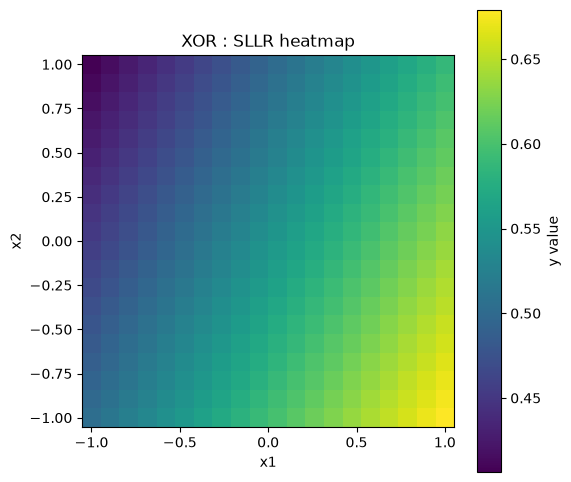

In [20]:
N = 20  # number of points along each axis

x1 = np.linspace(-1, 1, N)
x2 = np.linspace(-1, 1, N)
xx1, xx2 = np.meshgrid(x1, x2)

x_new = np.stack([xx1.ravel(), xx2.ravel()], axis=1)

y_new = model_predict(sllr, x_new)

y_grid_2d = y_new.reshape(N, N)

plt.figure(figsize=(6, 6))
plt.pcolormesh(xx1, xx2, y_grid_2d, cmap="viridis", shading="auto")
plt.colorbar(label="y value")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("XOR : SLLR heatmap")
plt.gca().set_aspect("equal")
plt.show()

# 4.2 now use a model with more layers

In [21]:
n = 200

model = nn.Sequential(
	nn.Linear(2,n),
	nn.ReLU(),
	nn.Linear(n,n),
	nn.ReLU(),
    nn.Linear(n,n),
	nn.ReLU(),
	nn.Linear(n,1),
	nn.Sigmoid()
	)

eta = 0.01
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = eta)
print(model)

Sequential(
  (0): Linear(in_features=2, out_features=200, bias=True)
  (1): ReLU()
  (2): Linear(in_features=200, out_features=200, bias=True)
  (3): ReLU()
  (4): Linear(in_features=200, out_features=200, bias=True)
  (5): ReLU()
  (6): Linear(in_features=200, out_features=1, bias=True)
  (7): Sigmoid()
)


In [22]:
num_epochs = 1000

train = train_model(model,
    x_train,
    y_train,
    loss_fn,
    optimizer,
    epochs = num_epochs,
    batch_size=32,
    metrics=None,
    X_val=x_valid,
    y_val=y_valid,
    validation_split=0.0,
    verbose_every=1,
    device=None,)

Epoch 1/1000, loss: 0.6965, val_loss: 0.6961
Epoch 2/1000, loss: 0.6959, val_loss: 0.6957
Epoch 3/1000, loss: 0.6952, val_loss: 0.6948
Epoch 4/1000, loss: 0.6941, val_loss: 0.6942
Epoch 5/1000, loss: 0.6933, val_loss: 0.6934
Epoch 6/1000, loss: 0.6925, val_loss: 0.6924
Epoch 7/1000, loss: 0.6913, val_loss: 0.6919
Epoch 8/1000, loss: 0.6907, val_loss: 0.6910
Epoch 9/1000, loss: 0.6900, val_loss: 0.6905
Epoch 10/1000, loss: 0.6893, val_loss: 0.6898
Epoch 11/1000, loss: 0.6885, val_loss: 0.6892
Epoch 12/1000, loss: 0.6877, val_loss: 0.6880
Epoch 13/1000, loss: 0.6867, val_loss: 0.6871
Epoch 14/1000, loss: 0.6857, val_loss: 0.6864
Epoch 15/1000, loss: 0.6846, val_loss: 0.6856
Epoch 16/1000, loss: 0.6839, val_loss: 0.6849
Epoch 17/1000, loss: 0.6832, val_loss: 0.6844
Epoch 18/1000, loss: 0.6824, val_loss: 0.6837
Epoch 19/1000, loss: 0.6816, val_loss: 0.6829
Epoch 20/1000, loss: 0.6808, val_loss: 0.6825
Epoch 21/1000, loss: 0.6804, val_loss: 0.6821
Epoch 22/1000, loss: 0.6799, val_loss: 0.68

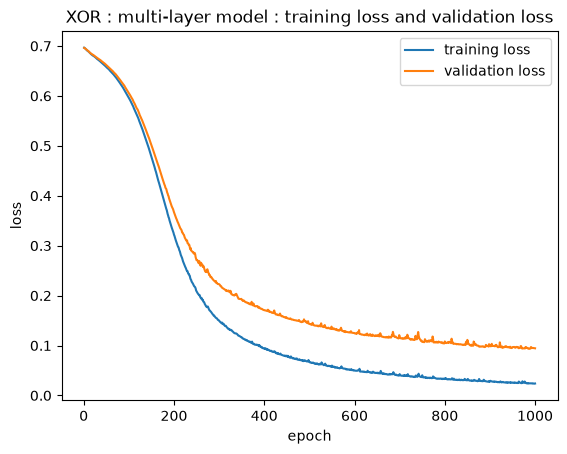

In [23]:
train_loss_vals = train['loss']
validation_loss_vals = train['val_loss']
epoch_vals = np.arange(1, len(train_loss_vals) + 1)

this_title = "XOR : multi-layer model : training loss and validation loss"
plt.plot(epoch_vals, train_loss_vals, label = "training loss")
plt.plot(epoch_vals, validation_loss_vals, label = "validation loss")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(this_title)
plt.show()

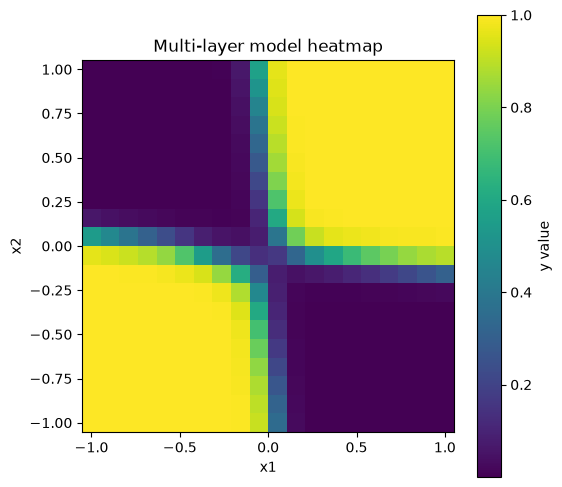

In [24]:
N = 20  # number of points along each axis

x1 = np.linspace(-1, 1, N)
x2 = np.linspace(-1, 1, N)
xx1, xx2 = np.meshgrid(x1, x2)
x_new = np.stack([xx1.ravel(), xx2.ravel()], axis=1)
y_new = model_predict(model, x_new)
y_grid_2d = y_new.reshape(N, N)

plt.figure(figsize=(6, 6))
plt.pcolormesh(xx1, xx2, y_grid_2d, cmap="viridis", shading="auto")
plt.colorbar(label="y value")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Multi-layer model heatmap")
plt.gca().set_aspect("equal")
plt.show()

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

def train_model(
    model,
    X,
    y,
    loss_fn,
    optimizer,
    epochs=100,
    batch_size=32,
    metrics=None,
    X_val=None,
    y_val=None,
    validation_split=0.0,
    verbose_every=10,
    device=None,
):
    """
    Generic training loop for a PyTorch model.

    Parameters
    ----------
    model : nn.Module
    X, y : torch.Tensor or np.ndarray  -- training data
    loss_fn : callable, e.g. nn.MSELoss(), nn.BCELoss()
    optimizer : torch.optim.Optimizer
    epochs : int
    batch_size : int
    metrics : dict[str, callable] or None
        Each callable takes (y_pred, y_true) and returns a float.
    X_val, y_val : optional validation data (same format as X, y)
        validation_split : float in [0.0, 1.0)
        Fraction of (X, y) to hold out as validation data, taken from the END of the dataset. 
        Ignored if X_val and y_val are both explicitly provided.
    verbose_every : int -- print progress every N epochs (0 to disable)
    device : torch.device or None -- defaults to CUDA if available, else CPU

    Returns
    -------
    history : dict of lists, e.g. {"loss": [...], "val_loss": [...], "accuracy": [...]}
    """
    if not (0.0 <= validation_split < 1.0):
        raise ValueError("validation_split must be in [0.0, 1.0)")

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    def to_tensor(a):
        if isinstance(a, np.ndarray):
            return torch.from_numpy(a).float()
        return a.float()

    X = to_tensor(X)
    y = to_tensor(y)

    # Handle validation_split (only if X_val/y_val not already given)
    if X_val is None and y_val is None and validation_split > 0.0:
        n_total = X.shape[0]
        n_val = int(round(n_total * validation_split))
        n_train = n_total - n_val

        X_val = X[n_train:]
        y_val = y[n_train:]
        X = X[:n_train]
        y = y[:n_train]
        print("n_total = ", n_total, "n_val = ", n_val, "n_train = ", n_train)

    dataset = TensorDataset(X, y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    has_val = X_val is not None and y_val is not None
    if has_val:
        X_val = to_tensor(X_val).to(device)
        y_val = to_tensor(y_val).to(device)

    metrics = metrics or {}

    history = {"loss": []}
    history.update({name: [] for name in metrics})
    if has_val:
        history["val_loss"] = []
        history.update({f"val_{name}": [] for name in metrics})

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_metrics = {name: 0.0 for name in metrics}
        n_samples = 0

        i = 0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_batch = y_batch.reshape(-1,1)
            i += 1

            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            bs = X_batch.size(0)
            running_loss += loss.item() * bs
            for name, fn in metrics.items():
                running_metrics[name] += fn(y_pred, y_batch) * bs
            n_samples += bs

        epoch_loss = running_loss / n_samples
        history["loss"].append(epoch_loss)
        for name in metrics:
            val = running_metrics[name] / n_samples
            history[name].append(val)

        log_str = f"Epoch {epoch+1}/{epochs}, loss: {epoch_loss:.4f}"
        for name in metrics:
            log_str += f", {name}: {history[name][-1]:.4f}"
            
        if has_val:
            model.eval()
            with torch.no_grad():
                y_val_pred = model(X_val)
                
                #print("y_val_pred.shape = ", y_val_pred.shape)
                y_val_pred = y_val_pred.reshape(-1,1)
                #print("y_val_pred.shape = ", y_val_pred.shape)
                #print("y_val.shape = ", y_val.shape)
                y_val = y_val.reshape(-1,1)
                #print("y_val.shape = ", y_val.shape)
                
                val_loss = loss_fn(y_val_pred, y_val).item()
                history["val_loss"].append(val_loss)
                log_str += f", val_loss: {val_loss:.4f}"
                for name, fn in metrics.items():
                    val_metric = fn(y_val_pred, y_val)
                    history[f"val_{name}"].append(val_metric)
                    log_str += f", val_{name}: {val_metric:.4f}"

        if verbose_every and (epoch + 1) % verbose_every == 0:
            print(log_str)

    return history
    
def model_predict(model, input_data):

	is_numpy_array = isinstance(input_data, np.ndarray)
	

	# 1. Make sure input_data is a float32 tensor
	if is_numpy_array:
		input_data = torch.from_numpy(input_data).float()
	else:
		input_data = input_data.float()

	# 2. Make sure it's on the same device as the model
	device = next(model.parameters()).device
	input_data = input_data.to(device)

	# 3. Set eval mode and disable gradient tracking for inference
	model.eval()
	with torch.no_grad():
		ppred = model(input_data)
		
	# 4. return as either numpy array or as tensor, depending on input type
	if is_numpy_array:
		# return as a numpy array
		ppred_np = ppred.cpu().numpy()
		return ppred_np
	else:
		return ppred